# Full System Simulation: Truss on Fixed Columns

This notebook visualizes the full structural system, including:
- A simply-supported 18-panel, 0.6m depth truss.
- Two rigid vertical support columns fixed at the base (-0.6m underground to 4m/5m elevation).
- Downward factored dead+wind loads of 2.3 kN/m on the truss chord.
- Lateral wind load of 1.6 kN/m acting on the left column.


In [1]:
from anastruct import SystemElements
import matplotlib.pyplot as plt

ss = SystemElements()

# 1. Truss Parameters
N = 18
depth = 0.6
L_total = 18.0
dy = 1.0 # difference in y from x=0 to x=18
dx = L_total / N
dy_per_panel = dy / N

# Create Truss Nodes and Elements
# Bottom chord
for i in range(N):
    x1, y1 = i * dx, 4 + i * dy_per_panel
    x2, y2 = (i + 1) * dx, 4 + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y1], [x2, y2]])

# Top chord
for i in range(N):
    x1, y1 = i * dx, 4 + depth + i * dy_per_panel
    x2, y2 = (i + 1) * dx, 4 + depth + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y1], [x2, y2]])

# Vertical web members
for i in range(N + 1):
    x, y_bottom = i * dx, 4 + i * dy_per_panel
    y_top = y_bottom + depth
    ss.add_truss_element(location=[[x, y_bottom], [x, y_top]])

# Diagonal web members
for i in range(N):
    x1, y_bottom = i * dx, 4 + i * dy_per_panel
    x2, y_top2 = (i + 1) * dx, 4 + depth + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y_bottom], [x2, y_top2]])

# 2. Add Columns
# Left Column: From (0, -0.6) to (0, 4)
# Right Column: From (18, -0.6) to (18, 5)
# We use standard element here so they can resist bending moment (anastruct defaults to Euler-Bernoulli beams)
ss.add_element(location=[[0, -0.6], [0, 4]])
ss.add_element(location=[[18, -0.6], [18, 5]])

# To ensure the truss acts as simply supported on top of the columns,
# we need to make sure the connection points (0,4) and (18,5) act as hinges 
# to prevent the transfer of bending moment from the truss into the columns.
# (Anastruct truss_elements inherently have hinged ends, so connecting a truss 
# element to a standard element automatically prevents moment transfer).

# 3. Add Supports
# Fixed supports at the base of the columns
col_base_left = ss.find_node_id([0, -0.6])
col_base_right = ss.find_node_id([18, -0.6])

ss.add_support_fixed(node_id=col_base_left)
ss.add_support_fixed(node_id=col_base_right)

# 4. Apply Loads
# Target the top chord elements which are added after the bottom chord elements
# The bottom chord elements are IDs 1 to N, top chord elements are N+1 to 2N
for i in range(N + 1, 2 * N + 1):
    # Apply downward load of 2.3 kN/m (negative Y direction)
    ss.q_load(q=-2.3, element_id=i, direction='y')

# Apply lateral wind load of 1.6 kN/m on the Left Column (+X direction)
# The left column is the 2nd to last element added in the script structure 
# (Total truss elements + 1)
total_truss_elements = N + N + (N + 1) + N # Bottom + Top + Verticals + Diagonals
left_column_id = total_truss_elements + 1
ss.q_load(q=1.6, element_id=left_column_id, direction='x')

# 5. Solve the System
print("Solving Structural System...")
ss.solve()
print("Solved successfully.")


Solving Structural System...
Solved successfully.


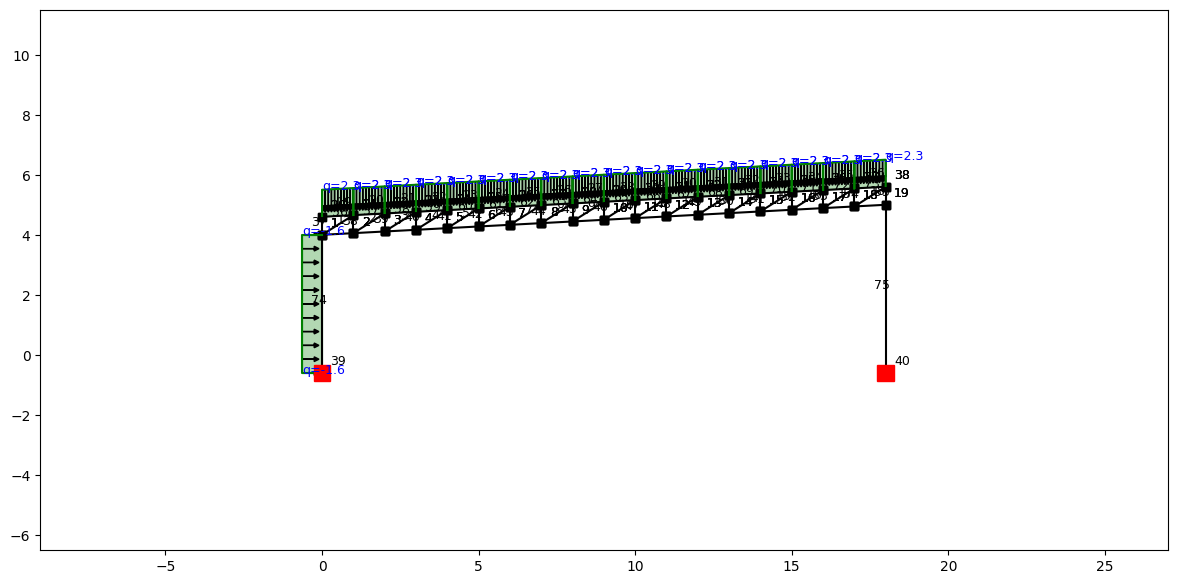

In [2]:
# Graph 1: Visualization of the Full System Structure
fig = ss.show_structure(show=True, figsize=(12, 6))


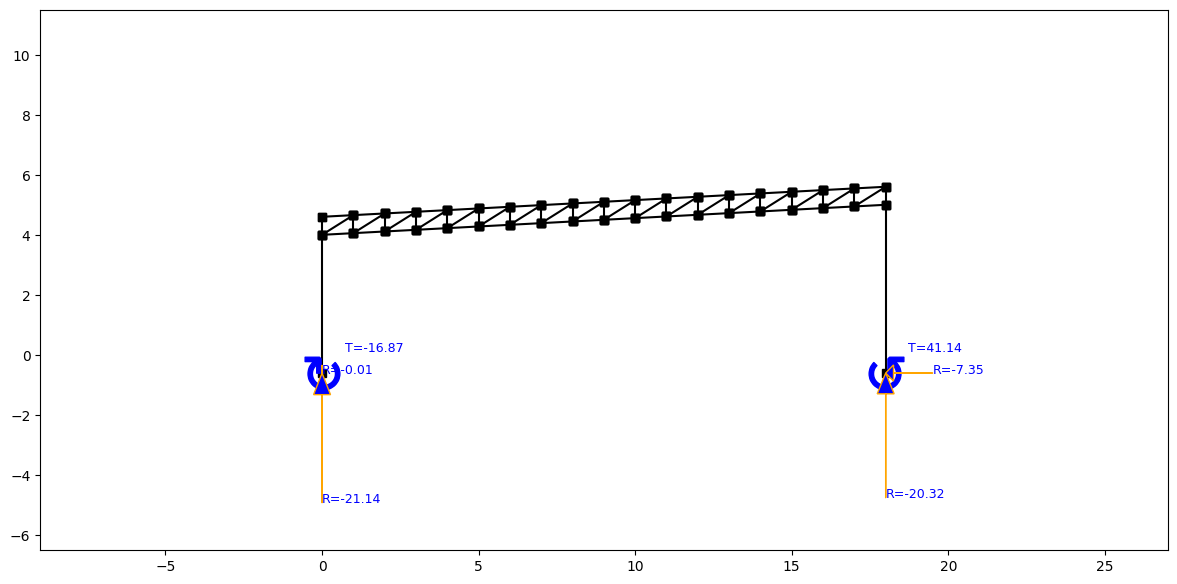

In [3]:
# Graph 2: Reaction Forces at Supports
fig = ss.show_reaction_force(show=True, figsize=(12, 6))


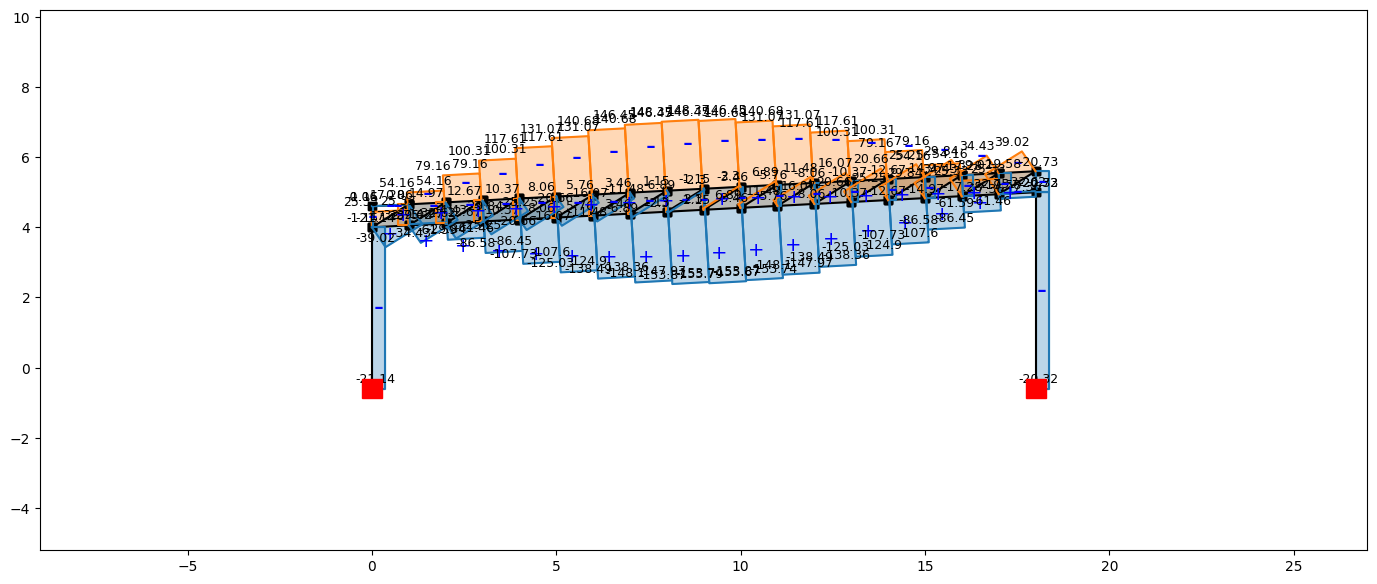

In [4]:
# Graph 3: Axial Forces (Tension / Compression)
# Useful for observing the forces distributed throughout the truss and compression in columns
fig = ss.show_axial_force(show=True, figsize=(14, 6))


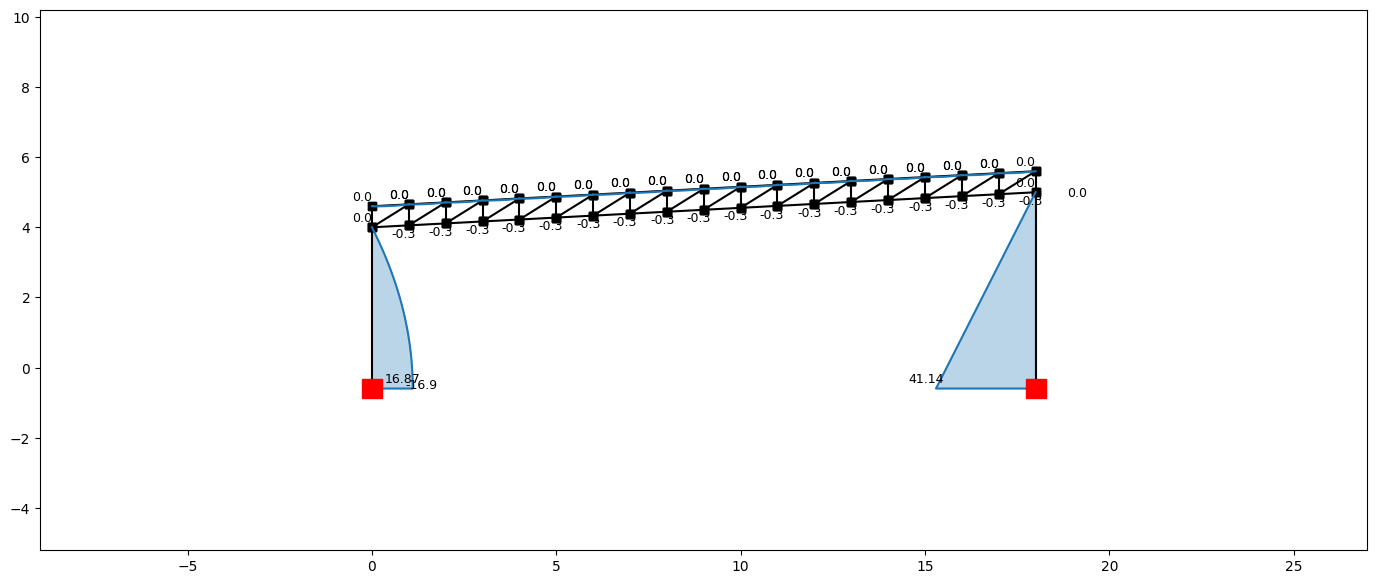

In [5]:
# Graph 4: Bending Moments
# Useful for observing the lateral wind moments induced on the fixed columns
fig = ss.show_bending_moment(show=True, figsize=(14, 6))
